In [6]:
import pandas as pd
import matplotlib.pyplot as plt

print("PRICES")
prices_df = pd.read_csv('data/prices_round_0_day_-1.csv', delimiter=';')
print(prices_df.head())

print("TRADES")
trades_df = pd.read_csv('data/trades_round_0_day_-1.csv', delimiter=';')
print(trades_df.head())

PRICES
   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  \
0   -1          0  TOMATOES         4999             5         4998   
1   -1          0  EMERALDS         9992            14         9990   
2   -1        100  EMERALDS         9992            11         9990   
3   -1        100  TOMATOES         5000             8         4998   
4   -1        200  EMERALDS         9992            15         9990   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0            15          NaN           NaN         5013             5   
1            29          NaN           NaN        10008            14   
2            22          NaN           NaN        10008            11   
3            21          NaN           NaN         5013             8   
4            20          NaN           NaN        10008            15   

   ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
0         5014            15          NaN           NaN  

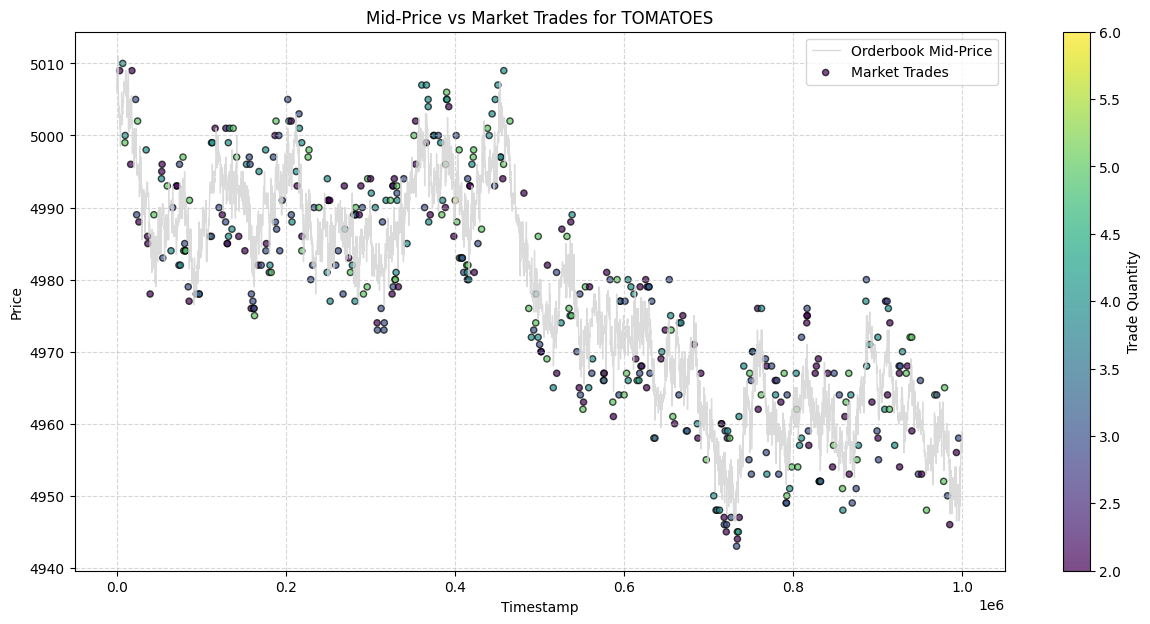

In [10]:
# 2. Filter for a specific product (e.g., 'AMETHYSTS' or 'STARFRUIT')
product = 'TOMATOES'
prod_prices = prices_df[prices_df['product'] == product].copy()
prod_trades = trades_df[trades_df['symbol'] == product].copy()

# 3. Calculate Mid-Price
# Mid-Price = (Best Bid + Best Ask) / 2
prod_prices['mid_price'] = (prod_prices['bid_price_1'] + prod_prices['ask_price_1']) / 2

# 4. Plotting
plt.figure(figsize=(15, 7))

# Plot the Mid-Price line (The "Book")
plt.plot(prod_prices['timestamp'], prod_prices['mid_price'], 
         label='Orderbook Mid-Price', color='lightgray', alpha=0.8, linewidth=1)

# Overlay the Market Trades (The "Action")
# We use a scatter plot because trades happen at discrete, "random" timestamps
plt.scatter(prod_trades['timestamp'], prod_trades['price'], 
            c=prod_trades['quantity'], cmap='viridis', label='Market Trades', 
            s=20, edgecolors='black', alpha=0.7)

plt.colorbar(label='Trade Quantity')
plt.title(f'Mid-Price vs Market Trades for {product}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Optional: Zoom in on a specific 5000ms window to see the "Lead" effect
# plt.xlim(10000, 15000) 

plt.show()